In [47]:
import numpy as np
import pandas as pd
import pingouin as pg
import statsmodels.api as sm
from statsmodels.formula.api import ols
from Toolbox.statistics.core import bootstrap

import seaborn as sns
from matplotlib import pyplot as plt

# fig1a

Ext. Data Fig. 1a — One-sample t-test: immobility > 0 during shock observation
               T  dof alternative     p_val            CI95   cohen_d     power     BF10
T_test  5.462438   13   two-sided  0.000109  [11.65, 26.88]  1.459898  0.998917  266.988

Ext. Data Fig. 1a — Independent t-test: RECALLER vs. NON-RECALLER
               T  dof alternative     p_val             CI95   cohen_d     power   BF10
T_test -0.139297   12   two-sided  0.891526  [-17.01, 14.96]  0.074457  0.051895  0.449


/tmp/ipykernel_2371612/1577081718.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=var, data=df,
/tmp/ipykernel_2371612/1577081718.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(y=var, data=df,
/tmp/ipykernel_2371612/1577081718.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(0, 55),


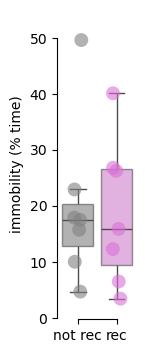

In [48]:
#load data
df = pd.read_parquet('SuppFig1a.parquet')

var = '%time immobile'

fig, ax = plt.subplots(1, 1, figsize=(1.0, 4))

sns.boxplot(y=var, data=df,
            x='context_learning', order=['not learned', 'learned'],
            palette=['grey', 'orchid'], fliersize=0.0,
            boxprops=dict(alpha=0.6))
sns.stripplot(y=var, data=df,
              x='context_learning', order=['not learned', 'learned'],
              palette=['grey', 'orchid'], dodge=False, size=10, alpha=0.6)

ax.set(ylim=(0, 55),
       xticklabels=['not rec', 'rec'],
       xlabel='', ylabel='immobility (% time)')
sns.despine(offset=True, trim=True)

# One-sample t-test: immobility > 0 during shock observation (all animals)
results_vs0 = pg.ttest(df.query("session == 'shock_observation'")[var], 0)
print("Ext. Data Fig. 1a — One-sample t-test: immobility > 0 during shock observation")
print(results_vs0.to_string())

# Independent t-test: RECALLER vs. NON-RECALLER
results_grp = pg.ttest(
    df.query("session == 'shock_observation' and context_learning == 'learned'")[var],
    df.query("session == 'shock_observation' and context_learning == 'not learned'")[var],
    paired=False)
print("\nExt. Data Fig. 1a — Independent t-test: RECALLER vs. NON-RECALLER")
print(results_grp.to_string())

# fig1b

(10, 20, 14)
float64


Text(3.75, 1.15, 'time (%)')

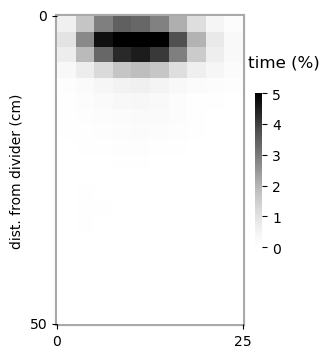

In [77]:
#load data
df_occup = pd.read_parquet('SuppFig1b.parquet')
df["occup"] = df_occup["occup"].apply(np.array)
occup = np.stack([
    np.stack(x, axis=0)    # (10, 20)
    for x in df_occup['occup']
], axis=2)

print(occup.shape)
print(occup.dtype)

fig, ax = plt.subplots(1, 1, figsize=(3,4), sharex=True, sharey=True)

sns.heatmap( np.mean(occup, axis=2).T,
            cmap='Greys', vmin=0, vmax=5,
            cbar_kws={'label': 'time (%)', "shrink": 0.5},
           ax=ax)


ax.set_xticks([0, 10])
ax.set_yticks([0, 20])

ax.set(
    # title='occupancy',
         # xticks=[0,25], 
         # yticks=[0, 50],
         xticklabels=[0,25], 
        yticklabels=[0,50],
         xlabel='', 
        ylabel='dist. from divider (cm)')
ax.patch.set_edgecolor('darkgrey')
ax.patch.set_linewidth(3)
# ax.patch.set_facecolor('darkgrey')
# plt.subplots_adjust(wspace=0.5)
cbar = ax.collections[0].colorbar

# Remove default label if any
cbar.set_label('')

# Add new label manually above the colorbar
cbar.ax.text(3.75, 1.15, 'time (%)',
             ha='center', va='bottom',
             transform=cbar.ax.transAxes,
             fontsize=12)


Ext. Data Fig. 1b — ANCOVA: occupancy ~ distance × recall status
                              df        sum_sq       mean_sq           F        PR(>F)
C(recall_status)             1.0      2.130336      2.130336    0.043589  8.347748e-01
distance                     1.0  11047.098472  11047.098472  226.033830  9.926276e-38
distance:C(recall_status)    1.0      1.459910      1.459910    0.029871  8.629097e-01
Residual                   276.0  13489.127639     48.873651         NaN           NaN

Intercept                                15.253085
C(recall_status)[T.RECALLER]             -0.412378
distance                                 -1.101827
distance:C(recall_status)[T.RECALLER]     0.025045
dtype: float64


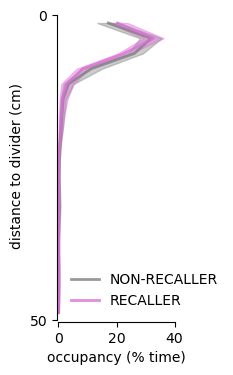

In [78]:
#load data
df_occup = pd.read_parquet('SuppFig1b.parquet')

prox_rec    = np.vstack(df_occup.query("context_learning == 'learned'")['proximity'])
prox_notrec = np.vstack(df_occup.query("context_learning == 'not learned'")['proximity'])

ci_rec    = bootstrap.ci(prox_rec,    axis=0, statistic=lambda x: np.nanmean(x, axis=0))
ci_notrec = bootstrap.ci(prox_notrec, axis=0, statistic=lambda x: np.nanmean(x, axis=0))

proxi = (np.arange(20) + 0.5) * 2.5   # bin centres in cm

fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))

ax.plot(np.nanmean(prox_notrec, axis=0), proxi,
        color='grey', label='NON-RECALLER', lw=2.0, alpha=0.8)
ax.fill_betweenx(proxi, ci_notrec[0], ci_notrec[1], color='grey', alpha=0.4)

ax.plot(np.nanmean(prox_rec, axis=0), proxi,
        color='orchid', label='RECALLER', lw=2.0, alpha=0.8)
ax.fill_betweenx(proxi, ci_rec[0], ci_rec[1], color='orchid', alpha=0.4)

ax.legend(frameon=False)
ax.set(xlim=(0, 40), ylim=(-0.5, 48), yticks=[0, 50],
       xlabel='occupancy (% time)', ylabel='distance to divider (cm)')
ax.invert_yaxis()
sns.despine(offset=True, trim=True)


#Statistics
# ANCOVA: effect of distance-to-divider on occupancy, controlling for recall status
df_prox = pd.DataFrame({
    'prox': np.concatenate([np.ravel(prox_rec), np.ravel(prox_notrec)]),
    'distance': np.concatenate([
        np.vstack(np.arange(prox_rec.shape[1]).tolist() * prox_rec.shape[0]).ravel(),
        np.vstack(np.arange(prox_notrec.shape[1]).tolist() * prox_notrec.shape[0]).ravel()
    ]),
    'recall_status': np.concatenate([
        np.array(['RECALLER']     * np.ravel(prox_rec).shape[0]),
        np.array(['NON-RECALLER'] * np.ravel(prox_notrec).shape[0])
    ])
})

model  = ols('prox ~ distance + C(recall_status) + distance:C(recall_status)',
             data=df_prox).fit()
result = sm.stats.anova_lm(model, type=2)

print("Ext. Data Fig. 1b — ANCOVA: occupancy ~ distance × recall status")
print(result.to_string())
print()
print(model.params)


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/tmp/ipykernel_2371612/1146055314.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=var,  data=df_occup,
/tmp/ipykernel_2371612/1146055314.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(y=var, data=df_occup,
/tmp/ipykernel_2371612/1146055314.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(


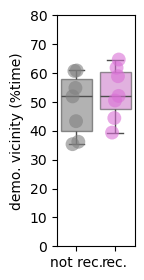

In [92]:
df_occup = pd.read_parquet('SuppFig1b.parquet')

var = 'demo_vicinity'

fig, ax = plt.subplots(1,1, figsize = (1.,3), sharey=False, sharex=False)


sns.boxplot(y=var,  data=df_occup,
              x='context_learning',
              order=['not learned', 'learned'],
                palette=['grey', 'orchid'], fliersize=0.0,
            boxprops=dict(alpha=.6)
           )
sns.stripplot(y=var, data=df_occup,
              x='context_learning',
              order=['not learned', 'learned'],
                palette=['grey', 'orchid'],
              dodge=False,
              size=10, alpha=0.6)

ax.set(
        ylim=(-0, 80), 
       xticklabels=['not rec.', 'rec.'],
      xlabel="",
      ylabel="demo. vicinity (%time)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['not rec.', 'rec.'], frameon=False)


var = 'demo_vicinity'
results2 = pg.ttest(df_occup[var], 0)
results3 = pg.ttest(
    df_occup.query("context_learning=='learned'")[var],
    df_occup.query("context_learning=='not learned'")[var],
    paired=False )

# fig1c

/tmp/ipykernel_2371612/779284494.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='context_learning', y='{}_{}'.format(metric, var),
/tmp/ipykernel_2371612/779284494.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='context_learning', y='{}_{}'.format(metric, var),
/tmp/ipykernel_2371612/779284494.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(-1.5, 4),
/tmp/ipykernel_2371612/779284494.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  

Ext. Data Fig. 1c — Independent t-test: Pupil diameter (RECALLER vs. NON-RECALLER)
               T  dof alternative     p_val          CI95   cohen_d     power BF10
T_test  2.572777    8   two-sided  0.032985  [0.16, 2.99]  1.627167  0.617372  2.4

Ext. Data Fig. 1c — Independent t-test: Eye movement (RECALLER vs. NON-RECALLER)
               T  dof alternative     p_val           CI95  cohen_d     power   BF10
T_test  2.017074    8   two-sided  0.078414  [-0.22, 3.32]  1.27571  0.426876  1.428



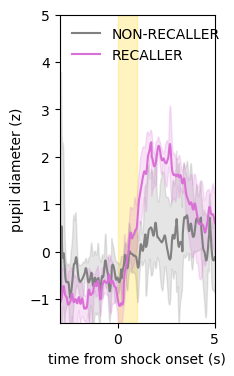

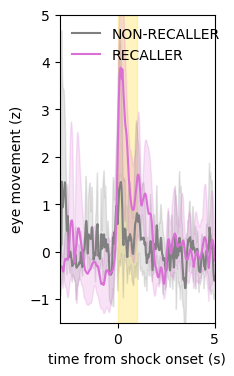

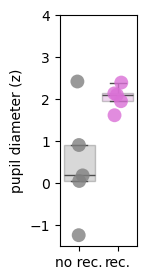

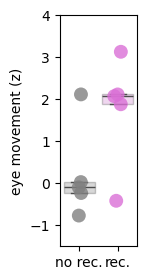

In [79]:
#load the data
df_ShockObs = pd.read_parquet('SuppFig1c.parquet')

# ── Time courses: pupil diameter and eye movement ─────────────────────────────
t = np.vstack(df_ShockObs.query("context_learning == 'learned'")['time_HM'].dropna())[0]

for var in ['pupil diameter (z)', 'eye movement (z)']:
    beh_rec    = np.vstack(df_ShockObs.query("context_learning == 'learned'")[var].dropna())
    beh_notrec = np.vstack(df_ShockObs.query("context_learning == 'not learned'")[var].dropna())

    ci_rec    = bootstrap.ci(beh_rec,    nsamples=500, alpha=0.05,
                             statistic=lambda x: np.nanmean(x, axis=0))
    ci_notrec = bootstrap.ci(beh_notrec, nsamples=500, alpha=0.05,
                             statistic=lambda x: np.nanmean(x, axis=0))

    fig = plt.figure(figsize=(2, 4))
    plt.axvspan(0, 1, color='gold', alpha=0.25)
    plt.fill_between(t, ci_notrec[0], ci_notrec[1], alpha=0.2, color='grey')
    plt.plot(t, np.nanmean(beh_notrec, axis=0), lw=1.5, color='grey',   label='NON-RECALLER')
    plt.fill_between(t, ci_rec[0],    ci_rec[1],    alpha=0.2, color='orchid')
    plt.plot(t, np.nanmean(beh_rec,    axis=0), lw=1.5, color='orchid', label='RECALLER')
    plt.legend(frameon=False, loc='upper left')
    plt.gca().set(ylim=(-1.5, 5), xlim=(-3, 5),
                  xlabel='time from shock onset (s)', ylabel=var)

# ── Boxplots of mean post-shock response ─────────────────────────────────────
metric = 'rep'
for var in ['pupil_diameter', 'eye_movement']:
    label = 'pupil diameter (z)' if var == 'pupil_diameter' else 'eye movement (z)'
    fig, ax = plt.subplots(1, 1, figsize=(1, 3))
    sns.boxplot(x='context_learning', y='{}_{}'.format(metric, var),
                data=df_ShockObs,
                order=['not learned', 'learned'],
                palette=['grey', 'orchid'],
                boxprops=dict(alpha=0.3), fliersize=0.0, ax=ax)
    sns.stripplot(x='context_learning', y='{}_{}'.format(metric, var),
                  data=df_ShockObs,
                  order=['not learned', 'learned'],
                  palette=['grey', 'orchid'],
                  size=10, alpha=0.8, ax=ax)
    ax.set(ylim=(-1.5, 4),
           xticklabels=['no rec.', 'rec.'],
           xlabel='', ylabel=label)


#Statistics
metric = 'rep'

for var, label in [('pupil_diameter', 'Pupil diameter'), ('eye_movement', 'Eye movement')]:
    ttest = pg.ttest(
        df_ShockObs.query("context_learning == 'learned'")['{}_{}'.format(metric, var)].dropna(),
        df_ShockObs.query("context_learning == 'not learned'")['{}_{}'.format(metric, var)].dropna())
    print("Ext. Data Fig. 1c — Independent t-test: {} (RECALLER vs. NON-RECALLER)".format(label))
    print(ttest.to_string())
    print()

# fig1d

/tmp/ipykernel_2371612/574106046.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='context_learning', y='{}_speed'.format(metric),


Ext. Data Fig. 1d — Independent t-test: orienting speed (RECALLER vs. NON-RECALLER)
               T  dof alternative     p_val          CI95   cohen_d     power   BF10
T_test -1.069941   12   two-sided  0.305695  [-3.0, 1.03]  0.571907  0.166661  0.645


/tmp/ipykernel_2371612/574106046.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='context_learning', y='{}_speed'.format(metric),
/tmp/ipykernel_2371612/574106046.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(0, 7.5),


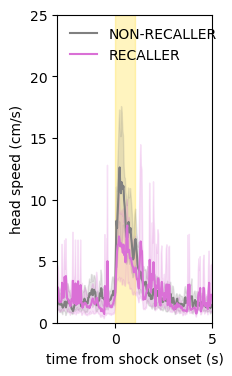

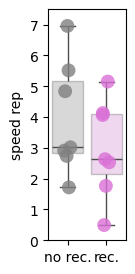

In [83]:
df_ShockObs = pd.read_parquet('SuppFig1d.parquet')


t = np.vstack(df_ShockObs.query("context_learning == 'learned'")['time'])[0]

# ── Speed time course ─────────────────────────────────────────────────────────
beh_rec    = np.vstack(df_ShockObs.query("context_learning == 'learned'")['speed'])
beh_notrec = np.vstack(df_ShockObs.query("context_learning == 'not learned'")['speed'])

ci_rec    = bootstrap.ci(beh_rec,    nsamples=500, alpha=0.05,
                         statistic=lambda x: np.nanmean(x, axis=0))
ci_notrec = bootstrap.ci(beh_notrec, nsamples=500, alpha=0.05,
                         statistic=lambda x: np.nanmean(x, axis=0))

fig = plt.figure(figsize=(2, 4))
plt.axvspan(0, 1, color='gold', alpha=0.25)
plt.fill_between(t, ci_notrec[0], ci_notrec[1], alpha=0.2, color='grey')
plt.plot(t, np.nanmean(beh_notrec, axis=0), lw=1.5, color='grey',   label='NON-RECALLER')
plt.fill_between(t, ci_rec[0],    ci_rec[1],    alpha=0.2, color='orchid')
plt.plot(t, np.nanmean(beh_rec,    axis=0), lw=1.5, color='orchid', label='RECALLER')
plt.legend(frameon=False, loc='upper left')
plt.gca().set(ylim=(0, 25), xlim=(-3, 5),
              xlabel='time from shock onset (s)', ylabel='head speed (cm/s)')

# ── Boxplot of mean post-shock speed ─────────────────────────────────────────
metric = 'rep'
fig, ax = plt.subplots(1, 1, figsize=(1, 3))
sns.boxplot(x='context_learning', y='{}_speed'.format(metric),
            data=df_ShockObs, order=['not learned', 'learned'],
            palette=['grey', 'orchid'],
            boxprops=dict(alpha=0.3), fliersize=0.0, ax=ax)
sns.stripplot(x='context_learning', y='{}_speed'.format(metric),
              data=df_ShockObs, order=['not learned', 'learned'],
              palette=['grey', 'orchid'],
              size=10, alpha=0.8, ax=ax)
ax.set(ylim=(0, 7.5),
       xticklabels=['no rec.', 'rec.'],
       xlabel='', ylabel='speed rep')

#statistics
ttest = pg.ttest(
    df_ShockObs.query("context_learning == 'learned'")['rep_speed'].dropna(),
    df_ShockObs.query("context_learning == 'not learned'")['rep_speed'].dropna())
print("Ext. Data Fig. 1d — Independent t-test: orienting speed (RECALLER vs. NON-RECALLER)")
print(ttest.to_string())

# fig1e

Ext. Data Fig. 1e — Independent t-test: distance-to-divider (RECALLER vs. NON-RECALLER)
             T  dof alternative     p_val           CI95  cohen_d     power  BF10
T_test  1.6059   12   two-sided  0.134274  [-0.52, 3.44]  0.85839  0.315348  0.99


/tmp/ipykernel_2371612/1700096854.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='context_learning', y='{}_distance'.format(metric),
/tmp/ipykernel_2371612/1700096854.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='context_learning', y='{}_distance'.format(metric),
/tmp/ipykernel_2371612/1700096854.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(-6, 6),


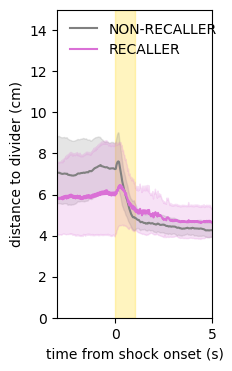

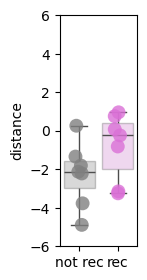

In [89]:
df_ShockObs = pd.read_parquet('SuppFig1e.parquet')


t = np.vstack(df_ShockObs.query("context_learning == 'learned'")['time'])[0]

# ── Distance time course ──────────────────────────────────────────────────────
beh_rec    = np.vstack(df_ShockObs.query("context_learning == 'learned'")['distance'])
beh_notrec = np.vstack(df_ShockObs.query("context_learning == 'not learned'")['distance'])

ci_rec    = bootstrap.ci(beh_rec,    nsamples=500, alpha=0.05,
                         statistic=lambda x: np.nanmean(x, axis=0))
ci_notrec = bootstrap.ci(beh_notrec, nsamples=500, alpha=0.05,
                         statistic=lambda x: np.nanmean(x, axis=0))

fig = plt.figure(figsize=(2, 4))
plt.axvspan(0, 1, color='gold', alpha=0.25)
plt.fill_between(t, ci_notrec[0], ci_notrec[1], alpha=0.2, color='grey')
plt.plot(t, np.nanmean(beh_notrec, axis=0), lw=1.5, color='grey',   label='NON-RECALLER')
plt.fill_between(t, ci_rec[0],    ci_rec[1],    alpha=0.2, color='orchid')
plt.plot(t, np.nanmean(beh_rec,    axis=0), lw=1.5, color='orchid', label='RECALLER')
plt.legend(frameon=False, loc='upper left')
plt.gca().set(ylim=(0, 15), xlim=(-3, 5),
              xlabel='time from shock onset (s)', ylabel='distance to divider (cm)')

# ── Boxplot of mean post-shock distance change ────────────────────────────────
metric = 'rep'
fig, ax = plt.subplots(1, 1, figsize=(1, 3))
sns.boxplot(x='context_learning', y='{}_distance'.format(metric),
            data=df_ShockObs, order=['not learned', 'learned'],
            palette=['grey', 'orchid'],
            boxprops=dict(alpha=0.3), fliersize=0.0, ax=ax)
sns.stripplot(x='context_learning', y='{}_distance'.format(metric),
              data=df_ShockObs, order=['not learned', 'learned'],
              palette=['grey', 'orchid'],
              size=10, alpha=0.8, ax=ax)
ax.set(ylim=(-6, 6),
       xticklabels=['not rec', 'rec'],
       xlabel='', ylabel='distance')

metric = 'rep'
ttest = pg.ttest(
    df_ShockObs.query("context_learning == 'learned'")['rep_distance'].dropna(),
    df_ShockObs.query("context_learning == 'not learned'")['rep_distance'].dropna())
print("Ext. Data Fig. 1e — Independent t-test: distance-to-divider (RECALLER vs. NON-RECALLER)")
print(ttest.to_string())

# fig1f

Ext. Data Fig. 1f — Two-way ANOVA: demonstrator vicinity (duo baseline) ~ context × recall status

                         Source           SS  DF           MS          F     p_unc       np2
0                     condition   365.651386   1   365.651386   2.102254  0.160026  0.080539
1              context_learning  3244.370752   1  3244.370752  18.652988  0.000235  0.437320
2  condition * context_learning   112.474288   1   112.474288   0.646653  0.429206  0.026237
3                      Residual  4174.392862  24   173.933036        NaN       NaN       NaN

                       Contrast condition        A            B Paired Parametric         T   dof alternative     p_unc    p_corr p_adjust     BF10     cohen
0                     condition         -     ctrl        shock  False       True -1.123536  26.0   two-sided  0.271477       NaN      NaN    0.565 -0.424657
1              context_learning         -  learned  not learned  False       True  4.258022  26.0   two-sided  0.000238

/tmp/ipykernel_2371612/560346991.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(0, 80),


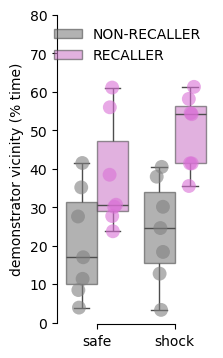

In [90]:

df_occup = pd.read_parquet('SuppFig1f.parquet')

var = 'demo_vicinity'

fig, ax = plt.subplots(1, 1, figsize=(2, 4))

sns.boxplot(y=var, data=df_occup,
            x='condition', hue='context_learning',
            hue_order=['not learned', 'learned'],
            palette=['grey', 'orchid'], fliersize=0.0,
            boxprops=dict(alpha=0.6))
sns.stripplot(y=var, data=df_occup,
              x='condition', hue='context_learning',
              hue_order=['not learned', 'learned'],
              palette=['grey', 'orchid'],
              dodge=True, size=10, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['NON-RECALLER', 'RECALLER'], frameon=False)
ax.set(ylim=(0, 80),
       xticklabels=['safe', 'shock'],
       xlabel='', ylabel='demonstrator vicinity (% time)')
sns.despine(offset=True, trim=True)


##Statistics
var     = 'demo_vicinity'
factor1 = 'condition'
factor2 = 'context_learning'
data    = df_occup[[var, factor1, factor2]]

results  = pg.anova(data=data, dv=var, between=[factor1, factor2], ss_type=2)
posthoc1 = pg.pairwise_tests(dv=var, between=[factor1, factor2],
                              padjust='holm', effsize='cohen', data=data)

print("Ext. Data Fig. 1f — Two-way ANOVA: demonstrator vicinity (duo baseline) ~ context × recall status")
print()
print(results.to_string())
print()
print(posthoc1.to_string())

# fig1g

Ext. Data Fig. 1f — Two-way ANOVA: demonstrator vicinity (duo baseline) ~ context × recall status

                         Source           SS  DF           MS         F     p_unc       np2
0                     condition   452.986195   1   452.986195  3.181566  0.087125  0.117049
1              context_learning  1356.801523   1  1356.801523  9.529547  0.005042  0.284213
2  condition * context_learning   552.029666   1   552.029666  3.877201  0.060597  0.139081
3                      Residual  3417.081381  24   142.378391       NaN       NaN       NaN

                       Contrast condition        A            B Paired Parametric         T   dof alternative     p_unc    p_corr p_adjust   BF10     cohen
0                     condition         -     ctrl        shock  False       True -1.487072  26.0   two-sided  0.149023       NaN      NaN  0.796 -0.562061
1              context_learning         -  learned  not learned  False       True  2.824429  26.0   two-sided  0.008974       Na

/tmp/ipykernel_2371612/2349550826.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(0, 80),


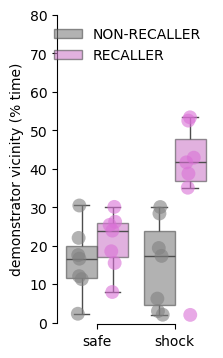

In [91]:

df_occup = pd.read_parquet('SuppFig1g.parquet')

var = 'demo_vicinity'

fig, ax = plt.subplots(1, 1, figsize=(2, 4))

sns.boxplot(y=var, data=df_occup,
            x='condition', hue='context_learning',
            hue_order=['not learned', 'learned'],
            palette=['grey', 'orchid'], fliersize=0.0,
            boxprops=dict(alpha=0.6))
sns.stripplot(y=var, data=df_occup,
              x='condition', hue='context_learning',
              hue_order=['not learned', 'learned'],
              palette=['grey', 'orchid'],
              dodge=True, size=10, alpha=0.6)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], ['NON-RECALLER', 'RECALLER'], frameon=False)
ax.set(ylim=(0, 80),
       xticklabels=['safe', 'shock'],
       xlabel='', ylabel='demonstrator vicinity (% time)')
sns.despine(offset=True, trim=True)


##Statistics
var     = 'demo_vicinity'
factor1 = 'condition'
factor2 = 'context_learning'
data    = df_occup[[var, factor1, factor2]]

results  = pg.anova(data=data, dv=var, between=[factor1, factor2], ss_type=2)
posthoc1 = pg.pairwise_tests(dv=var, between=[factor1, factor2],
                              padjust='holm', effsize='cohen', data=data)

print("Ext. Data Fig. 1f — Two-way ANOVA: demonstrator vicinity (duo baseline) ~ context × recall status")
print()
print(results.to_string())
print()
print(posthoc1.to_string())